# Why Logarithms are Used in Machine Learning
Explain the concept of monotonicity and why logarithms can always be applied in machine learning.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define a function to demonstrate monotonicity
def monotonic_function(x):
    return np.log(x)

# Generate data
x = np.linspace(0.1, 10, 100)
y = monotonic_function(x)

# Plot the function
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='y = log(x)')
plt.xlabel('x')
plt.ylabel('log(x)')
plt.title('Monotonicity of the Logarithm Function')
plt.legend()
plt.grid(True)
plt.show()

1. Today
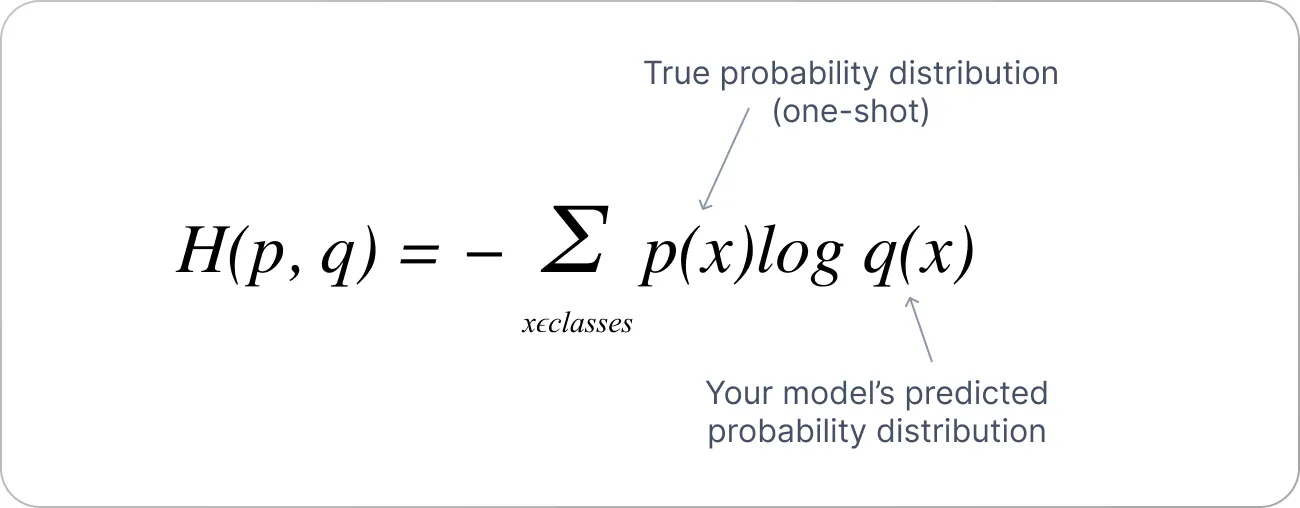

2. Friday
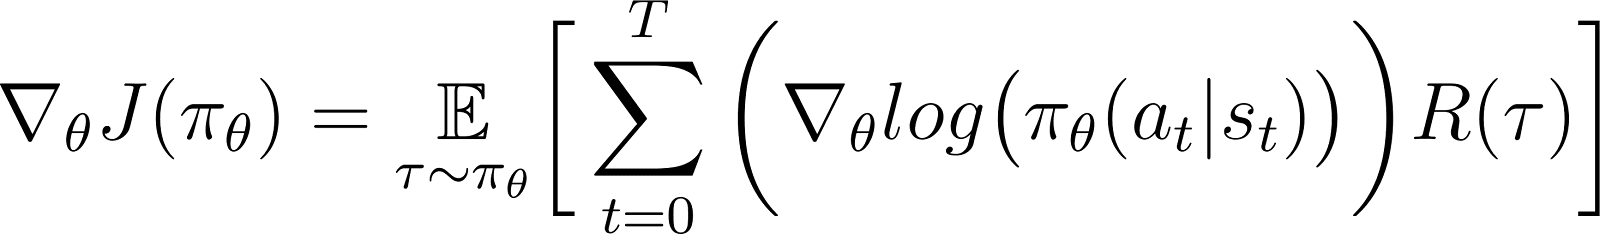


# Example: Classification Between 10 Semantic Classes
Provide an example of classification between 10 semantic classes and how cross entropy is computed.

In [ ]:
# Example: Classification Between 10 Semantic Classes

import numpy as np

# Define the true labels (one-hot encoded) for a batch of 3 samples
true_labels = np.array([
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Class 0
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],  # Class 1
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]   # Class 8
])

# Define the predicted probabilities for the same batch of samples
predicted_probabilities = np.array([
    [0.8, 0.05, 0.05, 0.05, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01],  # Predicted class 0 with high confidence
    [0.1, 0.7, 0.05, 0.05, 0.05, 0.01, 0.01, 0.01, 0.01, 0.01],   # Predicted class 1 with high confidence
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]            # Predicted all classes equally likely
])

# Compute the cross-entropy loss
cross_entropy_loss = -np.sum(true_labels * np.log(predicted_probabilities + 1e-15)) / true_labels.shape[0]

print(f"Cross-Entropy Loss: {cross_entropy_loss}")

# Visualize the true labels and predicted probabilities
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# True labels
ax[0].imshow(true_labels, cmap='viridis', aspect='auto')
ax[0].set_title('True Labels (One-Hot Encoded)')
ax[0].set_xlabel('Class')
ax[0].set_ylabel('Sample Index')

# Predicted probabilities
cax = ax[1].imshow(predicted_probabilities, cmap='viridis', aspect='auto')
ax[1].set_title('Predicted Probabilities')
ax[1].set_xlabel('Class')
ax[1].set_ylabel('Sample Index')
fig.colorbar(cax, ax=ax[1])

plt.show()

# Example: Natural Language Processing Prediction

# Cross Entropy in Semantic Segmentation
Compute the cross entropy for random guessing in semantic segmentation.

In [ ]:
import numpy as np

# Define the number of classes
num_classes = 10

# Define the true labels (one-hot encoded) for a batch of 3 samples
true_labels = np.array([
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Class 0
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],  # Class 1
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]   # Class 8
])

# Define the predicted probabilities for random guessing
predicted_probabilities = np.array([
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
])

# Compute the cross-entropy loss for random guessing
cross_entropy_loss_random_guessing = -np.sum(true_labels * np.log(predicted_probabilities + 1e-15)) / true_labels.shape[0]

print(f"Cross-Entropy Loss for Random Guessing in Semantic Segmentation: {cross_entropy_loss_random_guessing}")

# Visualize the true labels and predicted probabilities for random guessing
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# True labels
ax[0].imshow(true_labels, cmap='viridis', aspect='auto')
ax[0].set_title('True Labels (One-Hot Encoded)')
ax[0].set_xlabel('Class')
ax[0].set_ylabel('Sample Index')

# Predicted probabilities for random guessing
cax = ax[1].imshow(predicted_probabilities, cmap='viridis', aspect='auto')
ax[1].set_title('Predicted Probabilities (Random Guessing)')
ax[1].set_xlabel('Class')
ax[1].set_ylabel('Sample Index')
fig.colorbar(cax, ax=ax[1])

plt.show()

# Cross Entropy in Natural Language Processing
Compute the cross entropy for random guessing in natural language processing.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import AutoTokenizer

# Tokenizer (off-the-shelf)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Example sentence
sentence = "Perception and learning for robotics is great"
tokens = tokenizer(sentence, return_tensors="pt")
input_ids = tokens["input_ids"].squeeze(0)  # Remove batch dimension

print(f"Vocabulary size: ", tokenizer.vocab_size)
print(tokens)
print("Token Shape: ", tokens['input_ids'].shape)
print(f"Tokenized sentence: {tokenizer.convert_ids_to_tokens(input_ids.tolist())}")


# Jonas: One work != One token

In [ ]:
# Simple 2-layer MLP for next-token prediction
class MLP(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, vocab_size)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.embedding(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)  # No softmax, as CrossEntropyLoss includes it
        return x

# Model initialization
vocab_size = tokenizer.vocab_size
model = MLP(vocab_size)

# Prepare inputs and targets (shifted tokens for next-token prediction)
inputs = input_ids[:-1]  # All tokens except last
targets = input_ids[1:]  # All tokens except first

# Forward pass
outputs = model(inputs)

# Compute loss (CrossEntropyLoss expects raw logits)
criterion = nn.CrossEntropyLoss()
loss = criterion(outputs, targets)

print(f"Cross-entropy (randomly initialized model): {loss.item():.4f}")


In [ ]:
# Manually calculating cross entropy:
res = - 1 * np.log( 1/ 30522)
res